In [32]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [33]:
# CONFIG
DATA_PATH = "HBSC_data/HBSC2018OAed1.1.csv"
AGE_MIN = 13.0
AGE_MAX = 16.5
TARGET = "distress_score_100"

N_OOS_RUNS   = 5
TEST_SIZE    = 0.20
RANDOM_SEEDS = [11, 23, 37, 49, 61]
MIN_STRATUM_COUNT = 30

In [34]:
# HELPERS
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    items = df_items.dropna().copy()
    k = items.shape[1]
    if k <= 1:
        return np.nan
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def print_header(title: str):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

## Step 1 - Load and Filter Data

In [35]:
print_header("STEP 1 - LOAD DATA")
df = pd.read_csv(DATA_PATH, sep=";", engine="python")
print("Raw dataset shape:", df.shape)

# Filter age
df["age"] = pd.to_numeric(
    df["age"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
df = df[(df["age"] >= AGE_MIN) & (df["age"] <= AGE_MAX)].copy()
print(f"Filtered dataset shape (age {AGE_MIN}-{AGE_MAX}):", df.shape)


STEP 1 - LOAD DATA
Raw dataset shape: (244097, 120)
Filtered dataset shape (age 13.0-16.5): (156603, 120)


## Step 2 - Build Distress Target

**3-item emotional distress composite:** feellow, irritable, nervous

Dropped lifesat — it measures *evaluative wellbeing* (cognitive appraisal of life), not *emotional distress* (affective state). Including it adds construct-irrelevant noise.

Somatic symptoms (headache, stomachache, backache, dizzy) are kept as **predictors** — they are the observable signals schools can detect before students self-disclose.

In [36]:
print_header("STEP 2 - BUILD DISTRESS TARGET (3-item: feellow, irritable, nervous)")

# ── 3 core emotional distress items (lifesat DROPPED) ──
y_vars = ["feellow", "irritable", "nervous"]
for col in y_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Reverse so higher = more distress (original: 1=almost daily ... 5=rarely/never)
df["feellow_rev"]   = 6 - df["feellow"]
df["irritable_rev"] = 6 - df["irritable"]
df["nervous_rev"]   = 6 - df["nervous"]

reversed_y_vars = ["feellow_rev", "irritable_rev", "nervous_rev"]

df_y = df.dropna(subset=y_vars).copy()
print("Rows after dropping missing target items:", len(df_y))
print("Percent removed:", round((len(df) - len(df_y)) / len(df) * 100, 2), "%")

alpha_val = cronbach_alpha(df_y[reversed_y_vars])
print("Cronbach's alpha for 3-item distress scale:", round(alpha_val, 4))

# Z-score and rescale to 0-100
from sklearn.preprocessing import StandardScaler as _SS
_sc = _SS()
z_vars = [v + "_z" for v in reversed_y_vars]
df_y[z_vars] = _sc.fit_transform(df_y[reversed_y_vars])
df_y["distress_score_z"] = df_y[z_vars].mean(axis=1)

t_min = df_y["distress_score_z"].min()
t_max = df_y["distress_score_z"].max()
df_y["distress_score_100"] = (
    (df_y["distress_score_z"] - t_min) / (t_max - t_min)
) * 100

print(df_y["distress_score_100"].describe())


STEP 2 - BUILD DISTRESS TARGET (3-item: feellow, irritable, nervous)
Rows after dropping missing target items: 152656
Percent removed: 2.52 %
Cronbach's alpha for 3-item distress scale: 0.7759
count    152656.000000
mean         37.051574
std          28.559892
min           0.000000
25%          16.569051
50%          33.189785
75%          58.241467
max         100.000000
Name: distress_score_100, dtype: float64


## Step 3 - Target Exploration

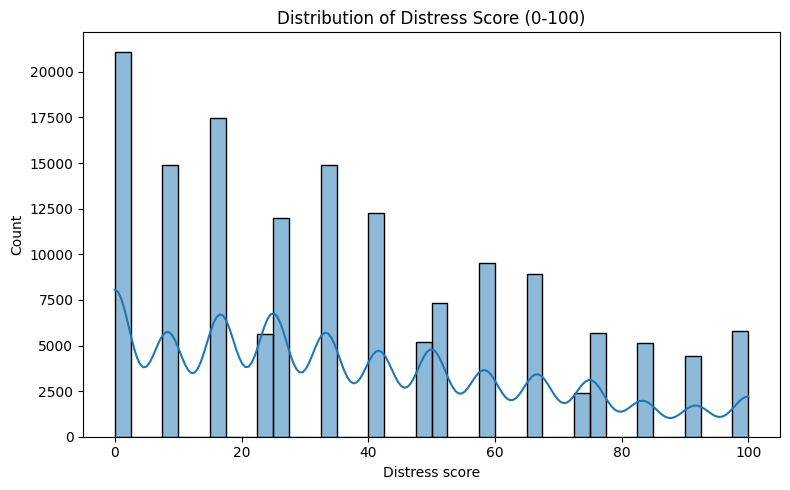

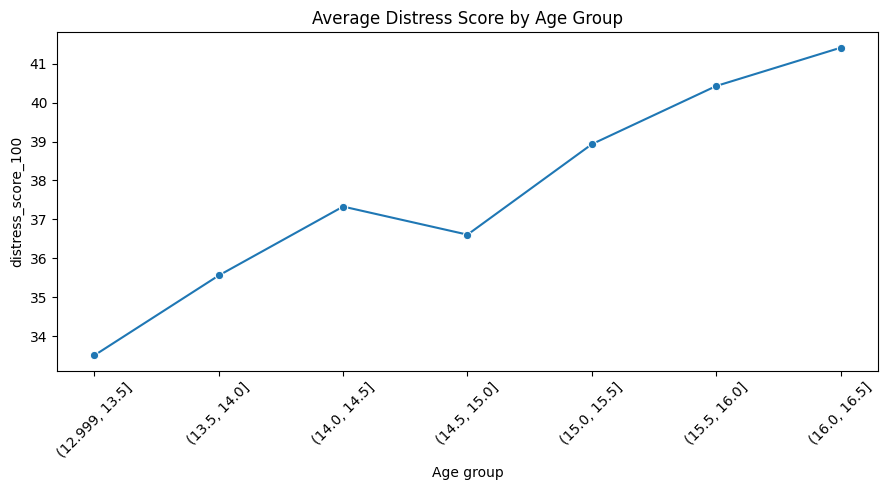

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df_y["distress_score_100"], bins=40, kde=True)
plt.title("Distribution of Distress Score (0-100)")
plt.xlabel("Distress score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df_y["age_bin"] = pd.cut(df_y["age"], bins=np.arange(13, 16.6, 0.5), include_lowest=True)
age_bin_mean = (
    df_y.groupby("age_bin", dropna=False)[TARGET]
    .mean()
    .reset_index()
)
age_bin_mean["age_bin"] = age_bin_mean["age_bin"].astype(str)

plt.figure(figsize=(9, 5))
sns.lineplot(data=age_bin_mean, x="age_bin", y=TARGET, marker="o")
plt.title("Average Distress Score by Age Group")
plt.xlabel("Age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 4 - Build Maximised Feature Set

**All features oriented so higher = more risk/distress. Country excluded (model targets Singaporean adolescents).**

Feature groups:
- **Demographics**: sex, age (continuous)
- **Somatic symptoms**: headache, stomachache, backache, dizzy
- **Sleep & health**: sleepdificulty, health
- **Body image & diet**: thinkbody, breakfastwd, breakfastwe, fruits, vegetables, sweets, softdrinks, toothbr
- **BMI**: MBMI (continuous)
- **Physical activity**: physact60, timeexe
- **School**: schoolpressure, likeschool, studaccept, studhelpful, studtogether
- **Teachers**: teacheraccept, teachercare, teachertrust
- **Bullying**: beenbullied, bulliedothers, cbeenbullied, cbulliedothers
- **Violence/injury**: fight12m, injured12m
- **Family**: famtalk, famsup, famdec, famhelp, fmeal, talkfather, talkmother, talkstepfa, talkstepmo
- **Family structure**: motherhome1, fatherhome1, stepmohome1, stepfahome1
- **Parent employment**: employfa, employmo
- **Friends**: friendhelp, friendcounton, friendshare, friendtalk
- **Substance use**: drunkltm, drunk30d, smokltm, smok30d_2, alcltm, alc30d_2, cannabisltm_2, cannabis30d_2
- **Social media**: emcsocmed1-9
- **Online contact**: emconlfreq1-4, emconlpref1-3
- **Family affluence**: IRFAS

In [38]:
print_header("STEP 4 - BUILD MAXIMISED RISK-ORIENTED FEATURES")

# ================================================================
# Convert all potential features to numeric
# ================================================================
all_potential = [
    "sex", "age",
    "headache", "stomachache", "backache", "dizzy",
    "sleepdificulty", "health",
    "thinkbody", "breakfastwd", "breakfastwe",
    "fruits_2", "vegetables_2", "sweets_2", "softdrinks_2", "toothbr",
    "MBMI",
    "physact60", "timeexe",
    "schoolpressure", "likeschool", "studaccept", "studhelpful", "studtogether",
    "teacheraccept", "teachercare", "teachertrust",
    "beenbullied", "bulliedothers", "cbeenbullied", "cbulliedothers",
    "fight12m", "injured12m",
    "famtalk", "famsup", "famdec", "famhelp", "fmeal",
    "talkfather", "talkmother", "talkstepfa", "talkstepmo",
    "motherhome1", "fatherhome1", "stepmohome1", "stepfahome1",
    "employfa", "employmo",
    "friendhelp", "friendcounton", "friendshare", "friendtalk",
    "drunkltm", "drunk30d", "smokltm", "smok30d_2", "alcltm", "alc30d_2",
    "cannabisltm_2", "cannabis30d_2",
    "emcsocmed1", "emcsocmed2", "emcsocmed3", "emcsocmed4", "emcsocmed5",
    "emcsocmed6", "emcsocmed7", "emcsocmed8", "emcsocmed9",
    "emconlfreq1", "emconlfreq2", "emconlfreq3", "emconlfreq4",
    "emconlpref1", "emconlpref2", "emconlpref3",
    "IRFAS",
]

for col in all_potential:
    if col in df_y.columns:
        df_y[col] = pd.to_numeric(df_y[col], errors="coerce")

# ================================================================
# RISK TRANSFORMATIONS: higher = more risk / more distress
# ================================================================

# --- Demographics ---
df_y["sex_risk"] = df_y["sex"]       # 1=male, 2=female; females higher distress
df_y["age_risk"] = df_y["age"]       # continuous; RF handles nonlinear age effects

# --- Somatic symptoms (already risk-oriented: higher = more frequent) ---
for col in ["headache", "stomachache", "backache", "dizzy"]:
    df_y[col + "_risk"] = df_y[col]

# --- Sleep & health ---
df_y["sleepdificulty_risk"] = 6 - df_y["sleepdificulty"]
df_y["health_risk"] = df_y["health"]  # higher = worse health

# --- Body image: distance from "about right" (3) ---
df_y["bodyimage_risk"] = (df_y["thinkbody"] - 3).abs()

# --- Diet (protective -> reverse) ---
for col in ["breakfastwd", "breakfastwe", "fruits_2", "vegetables_2"]:
    col_max = df_y[col].max()
    df_y[col + "_risk"] = col_max + 1 - df_y[col]
df_y["sweets_risk"] = df_y["sweets_2"]       # more sweets = risk
df_y["softdrinks_risk"] = df_y["softdrinks_2"]  # more softdrinks = risk

# Tooth brushing (protective -> reverse): higher = more brushing = good
df_y["toothbr_risk"] = df_y["toothbr"].max() + 1 - df_y["toothbr"]

# --- BMI (continuous) ---
df_y["bmi_risk"] = df_y["MBMI"]

# --- Physical activity (protective -> reverse) ---
df_y["physact_risk"] = df_y["physact60"].max() + 1 - df_y["physact60"]
df_y["timeexe_risk"] = df_y["timeexe"].max() + 1 - df_y["timeexe"]

# --- School (already risk-oriented: higher = worse) ---
for col in ["schoolpressure", "likeschool", "studaccept", "studhelpful", "studtogether"]:
    df_y[col + "_risk"] = df_y[col]

# --- Teachers (already risk-oriented) ---
for col in ["teacheraccept", "teachercare", "teachertrust"]:
    df_y[col + "_risk"] = df_y[col]

# --- Bullying (already risk-oriented) ---
for col in ["beenbullied", "bulliedothers", "cbeenbullied", "cbulliedothers"]:
    df_y[col + "_risk"] = df_y[col]

# --- Violence / injury (already risk-oriented) ---
df_y["fight12m_risk"] = df_y["fight12m"]
df_y["injured12m_risk"] = df_y["injured12m"]

# --- Family (protective -> reverse) ---
for col in ["famtalk", "famsup", "famdec", "famhelp"]:
    col_max = df_y[col].max()
    df_y[col + "_risk"] = col_max + 1 - df_y[col]
df_y["fmeal_risk"] = df_y["fmeal"].max() + 1 - df_y["fmeal"]

# Talk to parents: 5 = "don't have / don't see" -> treat as NaN, then reverse
for col in ["talkfather", "talkmother", "talkstepfa", "talkstepmo"]:
    if col in df_y.columns:
        temp = df_y[col].replace(5, np.nan)
        temp_max = temp.max()
        df_y[col + "_risk"] = temp_max + 1 - temp

# --- Family structure (binary: 1=present, 2=not) ---
for col in ["motherhome1", "fatherhome1"]:
    df_y[col + "_risk"] = df_y[col]  # 2 = not at home = higher risk
for col in ["stepmohome1", "stepfahome1"]:
    df_y[col + "_risk"] = 3 - df_y[col]  # 1->2(has step), 2->1(no step)

# --- Parent employment ---
for col in ["employfa", "employmo"]:
    if col in df_y.columns:
        df_y[col + "_risk"] = df_y[col]  # 2 = not employed = risk

# --- Friends (protective -> reverse) ---
for col in ["friendhelp", "friendcounton", "friendshare", "friendtalk"]:
    col_max = df_y[col].max()
    df_y[col + "_risk"] = col_max + 1 - df_y[col]

# --- Substance use (already risk) ---
for col in ["drunkltm", "drunk30d", "smokltm", "smok30d_2",
            "alcltm", "alc30d_2", "cannabisltm_2", "cannabis30d_2"]:
    df_y[col + "_risk"] = df_y[col]

# --- Social media (higher = more problematic use) ---
for col in ["emcsocmed1", "emcsocmed2", "emcsocmed3", "emcsocmed4", "emcsocmed5",
            "emcsocmed6", "emcsocmed7", "emcsocmed8", "emcsocmed9"]:
    df_y[col + "_risk"] = df_y[col]

# --- Online contact frequency and preferences ---
for col in ["emconlfreq1", "emconlfreq2", "emconlfreq3", "emconlfreq4",
            "emconlpref1", "emconlpref2", "emconlpref3"]:
    if col in df_y.columns:
        df_y[col + "_risk"] = df_y[col]

# --- Family affluence (lower = more risk -> reverse) ---
df_y["irfas_risk"] = df_y["IRFAS"].max() + 1 - df_y["IRFAS"]

# ================================================================
# COMPILE ALL RISK FEATURES (no country)
# ================================================================
feature_cols = [
    # Demographics
    "sex_risk", "age_risk",
    # Somatic
    "headache_risk", "stomachache_risk", "backache_risk", "dizzy_risk",
    # Sleep & health
    "sleepdificulty_risk", "health_risk",
    # Body image & diet
    "bodyimage_risk",
    "breakfastwd_risk", "breakfastwe_risk",
    "fruits_2_risk", "vegetables_2_risk", "sweets_risk", "softdrinks_risk",
    "toothbr_risk",
    # BMI
    "bmi_risk",
    # Physical activity
    "physact_risk", "timeexe_risk",
    # School
    "schoolpressure_risk", "likeschool_risk", "studaccept_risk",
    "studhelpful_risk", "studtogether_risk",
    # Teachers
    "teacheraccept_risk", "teachercare_risk", "teachertrust_risk",
    # Bullying
    "beenbullied_risk", "bulliedothers_risk", "cbeenbullied_risk", "cbulliedothers_risk",
    # Violence / injury
    "fight12m_risk", "injured12m_risk",
    # Family
    "famtalk_risk", "famsup_risk", "famdec_risk", "famhelp_risk", "fmeal_risk",
    "talkfather_risk", "talkmother_risk", "talkstepfa_risk", "talkstepmo_risk",
    # Family structure
    "motherhome1_risk", "fatherhome1_risk", "stepmohome1_risk", "stepfahome1_risk",
    # Parent employment
    "employfa_risk", "employmo_risk",
    # Friends
    "friendhelp_risk", "friendcounton_risk", "friendshare_risk", "friendtalk_risk",
    # Substance use
    "drunkltm_risk", "drunk30d_risk", "smokltm_risk", "smok30d_2_risk",
    "alcltm_risk", "alc30d_2_risk", "cannabisltm_2_risk", "cannabis30d_2_risk",
    # Social media
    "emcsocmed1_risk", "emcsocmed2_risk", "emcsocmed3_risk", "emcsocmed4_risk",
    "emcsocmed5_risk", "emcsocmed6_risk", "emcsocmed7_risk", "emcsocmed8_risk",
    "emcsocmed9_risk",
    # Online contact
    "emconlfreq1_risk", "emconlfreq2_risk", "emconlfreq3_risk", "emconlfreq4_risk",
    "emconlpref1_risk", "emconlpref2_risk", "emconlpref3_risk",
    # Family affluence
    "irfas_risk",
]

# Filter to columns that actually exist
feature_cols = [c for c in feature_cols if c in df_y.columns]

print(f"\nTotal features: {len(feature_cols)}")


STEP 4 - BUILD MAXIMISED RISK-ORIENTED FEATURES

Total features: 77


## Step 5 - Direction Audit

In [39]:
print_header("STEP 5 - DIRECTION AUDIT")
print(f"{'Feature':<30} {'Corr w/ distress':>16}  {'Direction':>10}")
print("-" * 60)

audit_issues = []
for col in feature_cols:
    valid = df_y[[col, TARGET]].dropna()
    if len(valid) > 100:
        r = valid[col].corr(valid[TARGET])
        direction = "+" if r > 0 else "NEGATIVE"
        print(f"{col:<30} {r:>+16.4f}  {direction}")
        if r < 0:
            audit_issues.append(col)

if audit_issues:
    print(f"\n{len(audit_issues)} variables with unexpected negative direction:")
    for v in audit_issues:
        print("  ", v)
    print("\nNote: Random Forest handles direction automatically, so negative")
    print("correlations are not fatal -- but worth reviewing for correctness.")
else:
    print("\nAll variables point in expected risk direction.")


STEP 5 - DIRECTION AUDIT
Feature                        Corr w/ distress   Direction
------------------------------------------------------------
sex_risk                                +0.2179  +
age_risk                                +0.0943  +
headache_risk                           -0.4358  NEGATIVE
stomachache_risk                        -0.3952  NEGATIVE
backache_risk                           -0.3430  NEGATIVE
dizzy_risk                              -0.4184  NEGATIVE
sleepdificulty_risk                     +0.4478  +
health_risk                             +0.3046  +
bodyimage_risk                          +0.2000  +
breakfastwd_risk                        +0.1705  +
breakfastwe_risk                        +0.1251  +
fruits_2_risk                           +0.0787  +
vegetables_2_risk                       +0.0562  +
sweets_risk                             +0.0710  +
softdrinks_risk                         +0.0281  +
toothbr_risk                            -0.0399  NEGATIVE
bm

## Step 6 - Build Working Dataset

In [40]:
print_header("STEP 6 - BUILD WORKING DATASET")

model_cols = feature_cols + [TARGET, "age", "sex"]
model_cols = list(dict.fromkeys(model_cols))  # deduplicate

working_df = df_y[model_cols].copy()
working_df = working_df[working_df[TARGET].notna()].copy()

print("Working dataframe shape:", working_df.shape)
print("Features:", len(feature_cols))

# Stratification for train/test split
working_df["age_band"] = pd.cut(
    working_df["age"],
    bins=[13, 14, 15, 16, 16.5],
    include_lowest=True
).astype(str)
working_df["sex_str"] = working_df["sex"].astype("Int64").astype(str)
working_df["strata"]  = working_df["age_band"] + "__" + working_df["sex_str"]

strata_counts = working_df["strata"].value_counts(dropna=False)
small_strata  = strata_counts[strata_counts < MIN_STRATUM_COUNT].index
working_df.loc[working_df["strata"].isin(small_strata), "strata"] = "other"

print("\nStrata counts:")
print(working_df["strata"].value_counts(dropna=False))

# Missing data summary
missing_pct = working_df[feature_cols].isnull().mean().sort_values(ascending=False)
print(f"\nMissing data % (top 15 features):")
print(missing_pct.head(15).to_string())


STEP 6 - BUILD WORKING DATASET
Working dataframe shape: (152656, 80)
Features: 77

Strata counts:
strata
(12.999, 14.0]__2    36354
(12.999, 14.0]__1    35037
(15.0, 16.0]__2      32248
(15.0, 16.0]__1      29845
(14.0, 15.0]__2       7272
(14.0, 15.0]__1       7013
(16.0, 16.5]__1       2511
(16.0, 16.5]__2       2376
Name: count, dtype: int64

Missing data % (top 15 features):
bmi_risk              0.996004
talkstepmo_risk       0.876074
talkstepfa_risk       0.843046
cannabis30d_2_risk    0.437808
cannabisltm_2_risk    0.428997
talkfather_risk       0.127280
emcsocmed8_risk       0.114729
emcsocmed9_risk       0.114316
emcsocmed7_risk       0.113877
emcsocmed6_risk       0.113733
emcsocmed5_risk       0.113124
emcsocmed4_risk       0.112947
emcsocmed1_risk       0.112573
emcsocmed3_risk       0.112102
emcsocmed2_risk       0.110765


## Step 7 - Feature Correlations


STEP 7 - QUICK FEATURE CORRELATIONS
            feature  correlation  abs_corr      n
sleepdificulty_risk     0.447846  0.447846 149670
      headache_risk    -0.435753  0.435753 152559
         dizzy_risk    -0.418361  0.418361 151685
   stomachache_risk    -0.395235  0.395235 152474
      backache_risk    -0.342991  0.342991 152342
schoolpressure_risk     0.306280  0.306280 150263
        health_risk     0.304553  0.304553 151831
    talkfather_risk    -0.291144  0.291144 133226
    talkmother_risk    -0.258070  0.258070 142423
    studaccept_risk     0.251600  0.251600 143348
       famtalk_risk     0.246506  0.246506 142727
    likeschool_risk     0.238729  0.238729 150459
  teachertrust_risk     0.223622  0.223622 143046
    talkstepfa_risk    -0.222878  0.222878  23960
 teacheraccept_risk     0.220171  0.220171 143493
   studhelpful_risk     0.219375  0.219375 143689
           sex_risk     0.217917  0.217917 152656
        famsup_risk     0.210309  0.210309 142725
   beenbullie

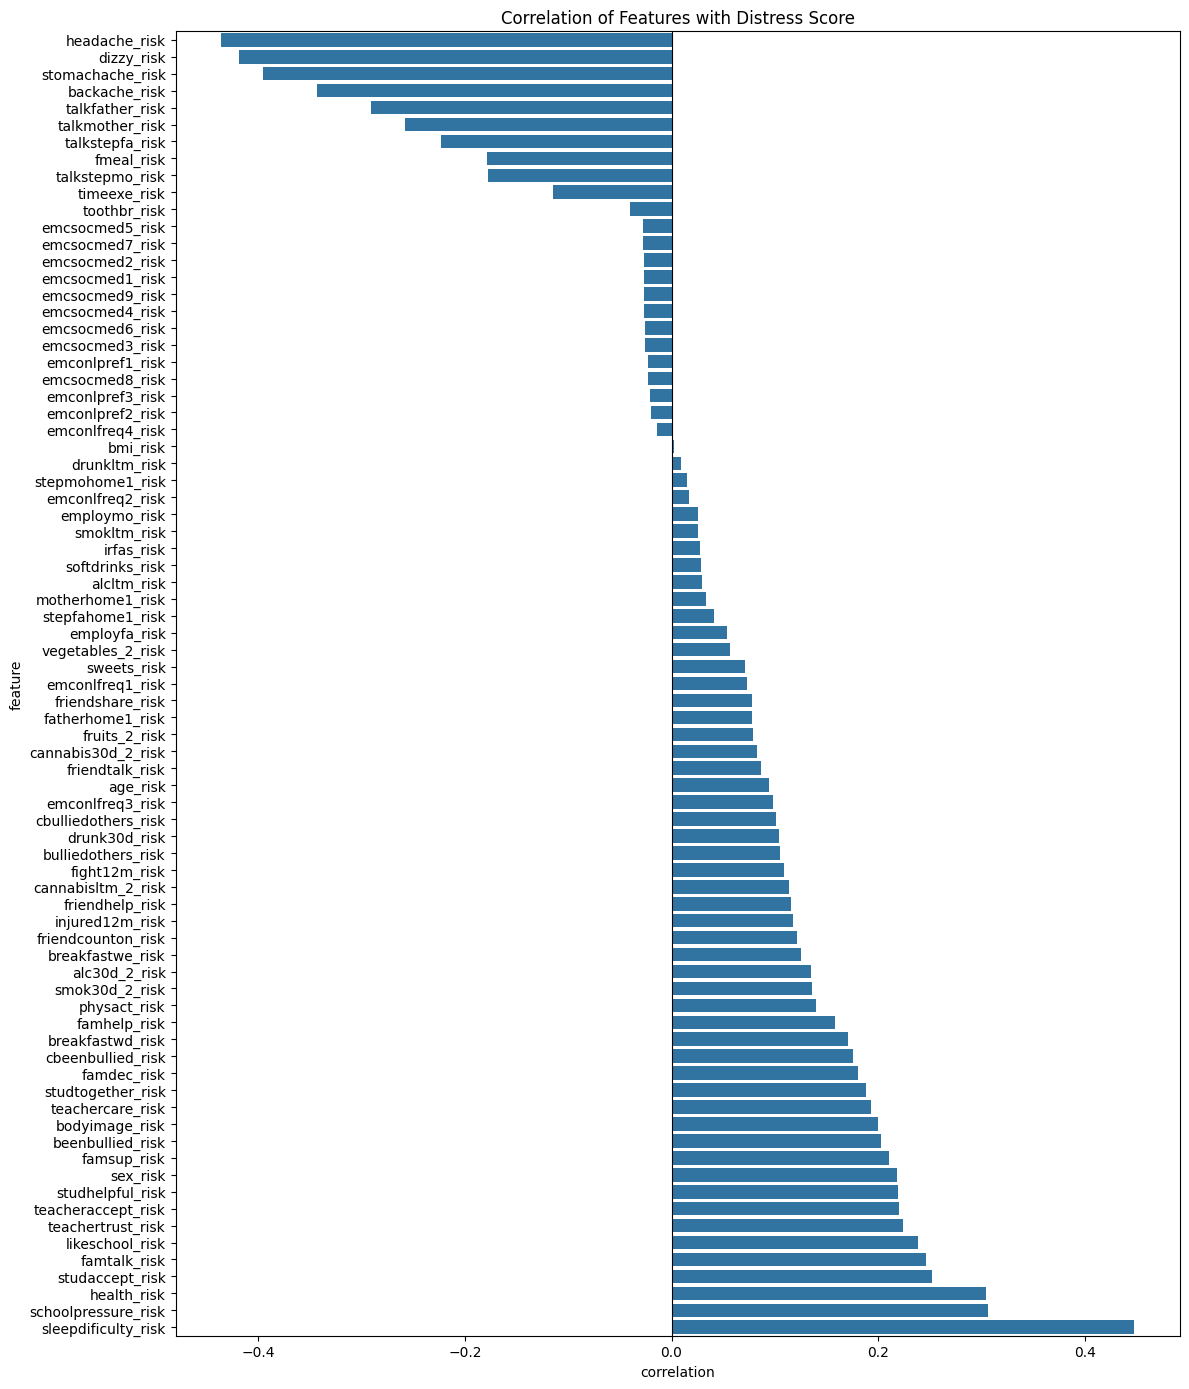

In [41]:
print_header("STEP 7 - QUICK FEATURE CORRELATIONS")

corr_rows = []
for col in feature_cols:
    valid = working_df[[col, TARGET]].dropna()
    if len(valid) > 500:
        r = valid[col].corr(valid[TARGET])
        corr_rows.append({"feature": col, "correlation": r, "abs_corr": abs(r), "n": len(valid)})

corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
print(corr_df.to_string(index=False))

plt.figure(figsize=(12, 14))
sns.barplot(data=corr_df.sort_values("correlation"), x="correlation", y="feature")
plt.title("Correlation of Features with Distress Score")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Step 8 - Define Models

Two models:
1. **ElasticNet** (linear baseline) - for comparison
2. **Random Forest** (nonlinear) - aggressive params: 800 trees, unlimited depth, min_samples_leaf=5, max_features=0.5

In [42]:
print_header("STEP 8 - DEFINE MODELS")

# Linear baseline (needs imputation + scaling)
elasticnet_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   ElasticNetCV(
        cv        = 5,
        l1_ratio  = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        n_alphas  = 100,
        max_iter  = 100000,
        random_state = 42
    ))
])

# Random Forest — aggressive settings for maximum R²
# n_estimators=800:   more trees = more stable predictions
# max_depth=None:     let trees grow fully (no artificial limit)
# min_samples_leaf=5: fine-grained splits (overfitting controlled by averaging 800 trees)
# max_features=0.5:   each tree sees 50% of features (better than sqrt≈8 with 68 features)
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(
        n_estimators    = 800,
        max_depth       = None,
        min_samples_leaf = 5,
        max_features    = 0.5,
        n_jobs          = -1,
        random_state    = 42,
    ))
])

print("ElasticNet pipeline ready.")
print("Random Forest pipeline ready (800 trees, max_depth=None, min_leaf=5, max_features=0.5).")


STEP 8 - DEFINE MODELS
ElasticNet pipeline ready.
Random Forest pipeline ready (800 trees, max_depth=None, min_leaf=5, max_features=0.5).


## Step 9 - Prepare Data for OOS Validation

No hyperparameter search — RF params hardcoded in Step 8 based on prior tuning results.
This avoids the slow RandomizedSearchCV loop entirely.

In [43]:
print_header("STEP 9 - PREPARE DATA")

X_all      = working_df[feature_cols].copy()
y_all      = working_df[TARGET].copy()
strata_all = working_df["strata"].copy()

# Use rf_pipeline directly (params already set in Step 8)
tuned_rf_pipeline = rf_pipeline

print(f"X shape: {X_all.shape}")
print(f"y shape: {y_all.shape}")
print(f"RF params: n_estimators=800, max_depth=None, min_samples_leaf=5, max_features=0.5")
print("Ready for OOS validation.")


STEP 9 - PREPARE DATA
X shape: (152656, 77)
y shape: (152656,)
RF params: n_estimators=800, max_depth=None, min_samples_leaf=5, max_features=0.5
Ready for OOS validation.


## Step 10 - 5 Repeated OOS Validations (Both Models)

In [44]:
print_header("STEP 10 - 5 REPEATED OOS VALIDATIONS")

models = {
    "ElasticNet":    elasticnet_pipeline,
    "RandomForest":  tuned_rf_pipeline,
}

all_oos_results = []
rf_importances = []

for model_name, base_model in models.items():
    print(f"\n--- {model_name} ---")
    for run_id, seed in enumerate(RANDOM_SEEDS[:N_OOS_RUNS], start=1):
        X_train, X_test, y_train, y_test, _, _ = train_test_split(
            X_all, y_all, strata_all,
            test_size=TEST_SIZE, random_state=seed, stratify=strata_all
        )

        m = clone(base_model)
        m.fit(X_train, y_train)

        y_pred_train = m.predict(X_train)
        y_pred_test  = m.predict(X_test)

        row = {
            "model":     model_name,
            "run":       run_id,
            "seed":      seed,
            "train_r2":  r2_score(y_train, y_pred_train),
            "test_r2":   r2_score(y_test,  y_pred_test),
            "train_rmse": rmse(y_train, y_pred_train),
            "test_rmse":  rmse(y_test,  y_pred_test),
            "train_mae": mean_absolute_error(y_train, y_pred_train),
            "test_mae":  mean_absolute_error(y_test,  y_pred_test),
        }
        all_oos_results.append(row)

        # Collect RF feature importances
        if model_name == "RandomForest":
            imp = m.named_steps["model"].feature_importances_
            rf_importances.append(pd.DataFrame({
                "run": run_id, "feature": feature_cols, "importance": imp
            }))

        print(f"  Run {run_id}: train_r2={row['train_r2']:.4f}, test_r2={row['test_r2']:.4f}, test_rmse={row['test_rmse']:.2f}")

oos_df = pd.DataFrame(all_oos_results)


STEP 10 - 5 REPEATED OOS VALIDATIONS

--- ElasticNet ---
  Run 1: train_r2=0.4542, test_r2=0.4525, test_rmse=21.12
  Run 2: train_r2=0.4543, test_r2=0.4513, test_rmse=21.14
  Run 3: train_r2=0.4536, test_r2=0.4549, test_rmse=21.06
  Run 4: train_r2=0.4535, test_r2=0.4544, test_rmse=21.19
  Run 5: train_r2=0.4552, test_r2=0.4483, test_rmse=21.11

--- RandomForest ---
  Run 1: train_r2=0.7728, test_r2=0.4617, test_rmse=20.94
  Run 2: train_r2=0.7722, test_r2=0.4660, test_rmse=20.86
  Run 3: train_r2=0.7719, test_r2=0.4692, test_rmse=20.78
  Run 4: train_r2=0.7725, test_r2=0.4639, test_rmse=21.00
  Run 5: train_r2=0.7728, test_r2=0.4606, test_rmse=20.87


## Step 11 - Compare Models


STEP 11 - MODEL COMPARISON
              mean_test_r2  std_test_r2  mean_test_rmse  std_test_rmse  mean_test_mae  std_test_mae  mean_train_r2
model                                                                                                             
ElasticNet          0.4523       0.0027         21.1236         0.0469        16.7701        0.0375         0.4542
RandomForest        0.4643       0.0034         20.8908         0.0827        16.5641        0.0567         0.7725

R2 improvement:   0.4523 -> 0.4643 (+0.0120)
RMSE improvement: 21.12 -> 20.89 (-0.23)


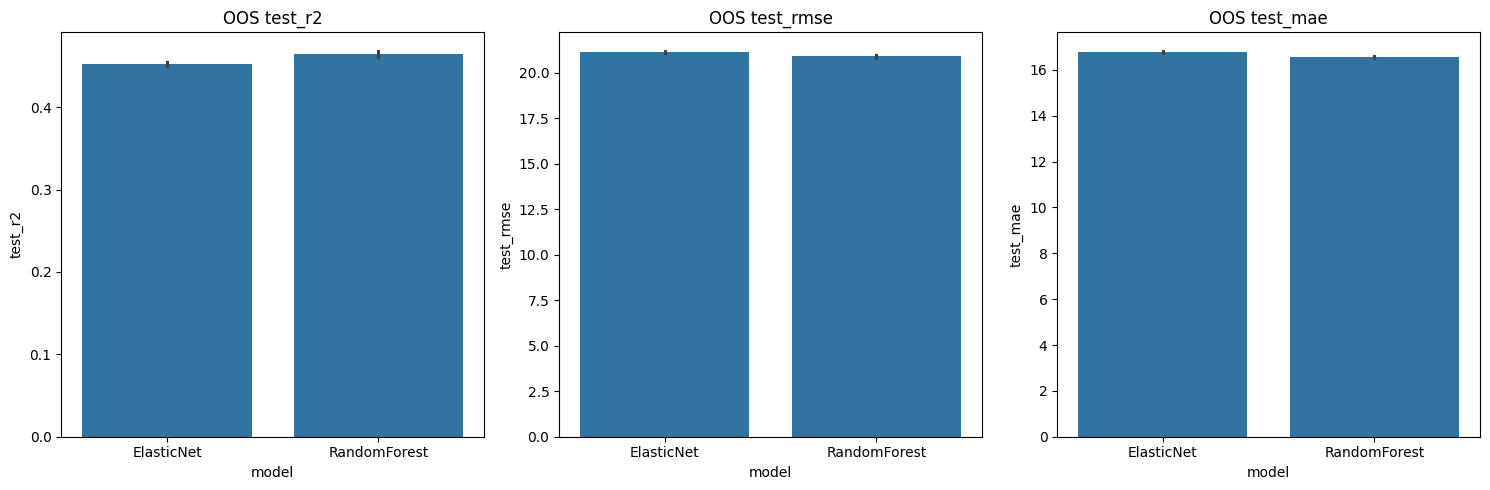

In [45]:
print_header("STEP 11 - MODEL COMPARISON")

comparison = (
    oos_df.groupby("model")
    .agg(
        mean_test_r2   = ("test_r2",   "mean"),
        std_test_r2    = ("test_r2",   "std"),
        mean_test_rmse = ("test_rmse", "mean"),
        std_test_rmse  = ("test_rmse", "std"),
        mean_test_mae  = ("test_mae",  "mean"),
        std_test_mae   = ("test_mae",  "std"),
        mean_train_r2  = ("train_r2",  "mean"),
    )
    .round(4)
)
print(comparison.to_string())

# Improvement
en_r2   = comparison.loc["ElasticNet",   "mean_test_r2"]
rf_r2   = comparison.loc["RandomForest", "mean_test_r2"]
en_rmse  = comparison.loc["ElasticNet",   "mean_test_rmse"]
rf_rmse  = comparison.loc["RandomForest", "mean_test_rmse"]

print(f"\nR2 improvement:   {en_r2:.4f} -> {rf_r2:.4f} (+{rf_r2 - en_r2:.4f})")
print(f"RMSE improvement: {en_rmse:.2f} -> {rf_rmse:.2f} ({rf_rmse - en_rmse:.2f})")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(["test_r2", "test_rmse", "test_mae"]):
    sns.barplot(data=oos_df, x="model", y=metric, ax=axes[i], errorbar="sd")
    axes[i].set_title(f"OOS {metric}")
plt.tight_layout()
plt.show()

## Step 12 - Random Forest Feature Importance


STEP 12 - RANDOM FOREST FEATURE IMPORTANCE
Top 20 features by importance:
            feature  mean_importance  std_importance
sleepdificulty_risk         0.169077        0.000674
      headache_risk         0.117185        0.001447
         dizzy_risk         0.072901        0.001302
   stomachache_risk         0.055865        0.000862
schoolpressure_risk         0.044106        0.000490
      backache_risk         0.031349        0.000344
           age_risk         0.023297        0.000099
    emcsocmed8_risk         0.022420        0.000329
    talkfather_risk         0.019458        0.000676
         irfas_risk         0.017703        0.000059
       famtalk_risk         0.015791        0.000438
        health_risk         0.014657        0.000430
       physact_risk         0.014626        0.000122
    studaccept_risk         0.013951        0.000344
        sweets_risk         0.013030        0.000049
    softdrinks_risk         0.011643        0.000042
    talkmother_risk     

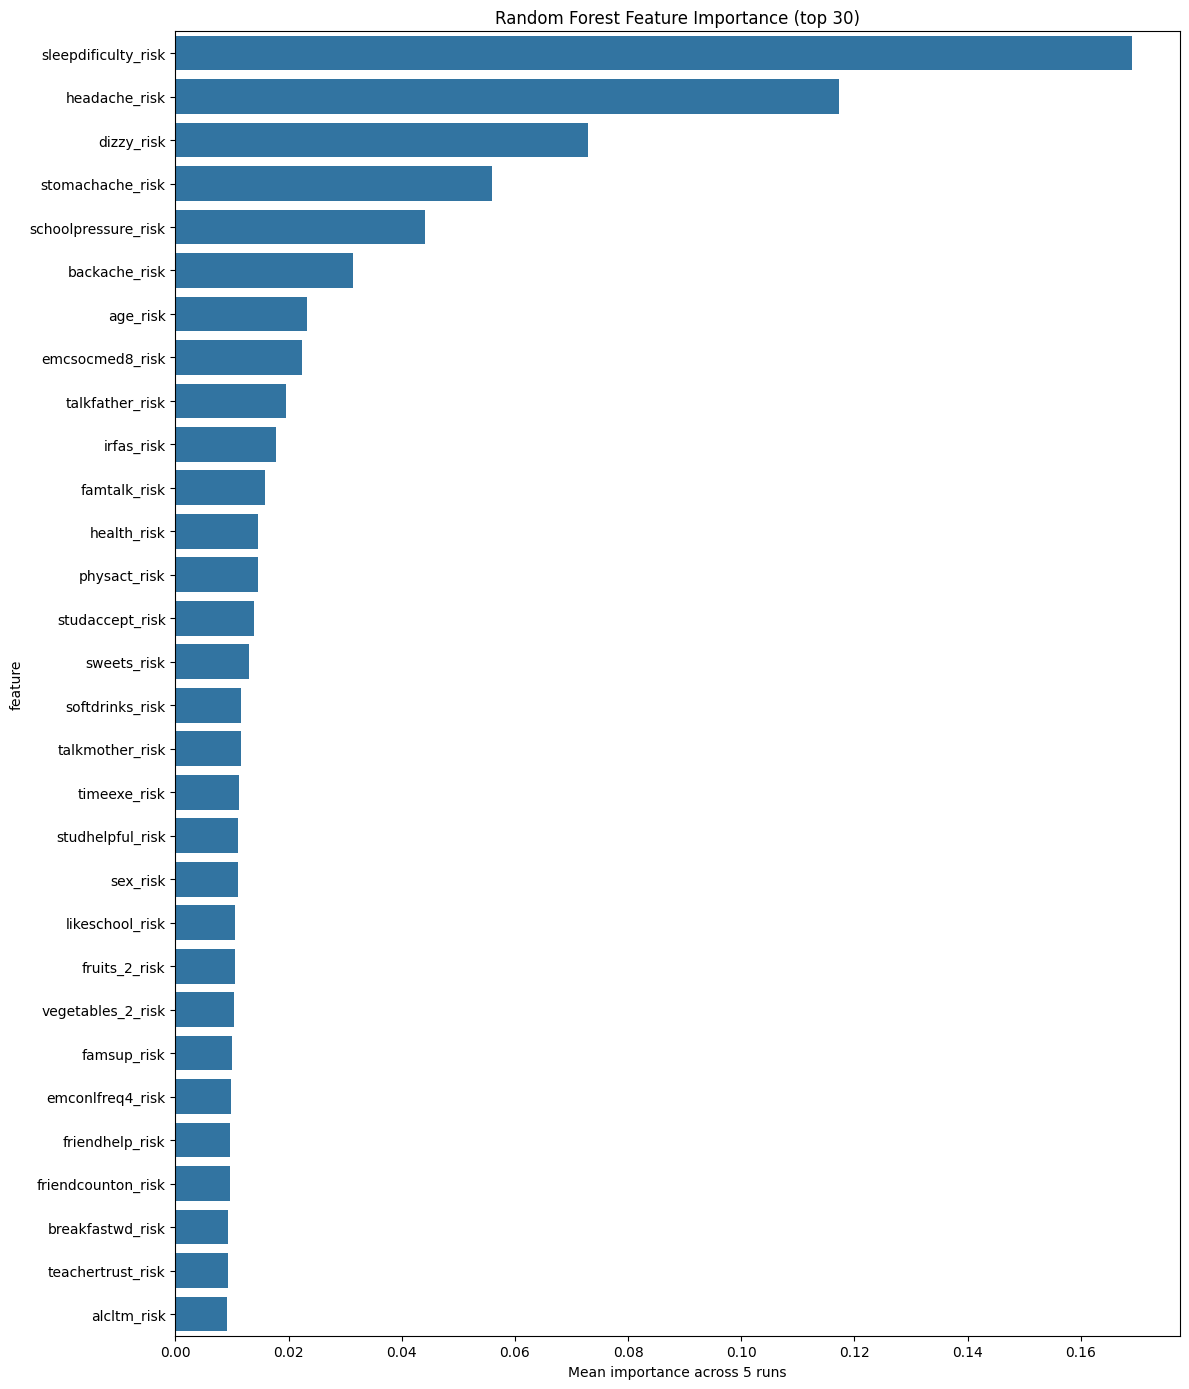

In [46]:
print_header("STEP 12 - RANDOM FOREST FEATURE IMPORTANCE")

imp_df = pd.concat(rf_importances, ignore_index=True)
imp_summary = (
    imp_df.groupby("feature")
    .agg(
        mean_importance = ("importance", "mean"),
        std_importance  = ("importance", "std"),
    )
    .sort_values("mean_importance", ascending=False)
    .reset_index()
)

print("Top 20 features by importance:")
print(imp_summary.head(20).to_string(index=False))

plt.figure(figsize=(12, 14))
sns.barplot(
    data=imp_summary.head(30),
    x="mean_importance", y="feature"
)
plt.title("Random Forest Feature Importance (top 30)")
plt.xlabel("Mean importance across 5 runs")
plt.tight_layout()
plt.show()

## Step 13 - Final Random Forest Model on Full Sample

In [47]:
print_header("STEP 13 - FINAL RF MODEL ON FULL SAMPLE")

final_rf = clone(tuned_rf_pipeline)
final_rf.fit(X_all, y_all)

full_pred = final_rf.predict(X_all)
diagnostic_df = working_df.copy()
diagnostic_df["predicted_distress"] = full_pred
diagnostic_df["residual"]           = full_pred - diagnostic_df[TARGET]
diagnostic_df["abs_error"]          = diagnostic_df["residual"].abs()

in_sample_r2 = r2_score(diagnostic_df[TARGET], full_pred)
rf_mean_oos = oos_df[oos_df["model"] == "RandomForest"]["test_r2"].mean()
print(f"In-sample R2: {in_sample_r2:.4f}")
print(f"Mean OOS R2:  {rf_mean_oos:.4f}")
print(f"Overfit gap:  {in_sample_r2 - rf_mean_oos:.4f}")


STEP 13 - FINAL RF MODEL ON FULL SAMPLE
In-sample R2: 0.7731
Mean OOS R2:  0.4643
Overfit gap:  0.3088


## Step 14 - Final Diagnostics


STEP 14 - FINAL DIAGNOSTICS


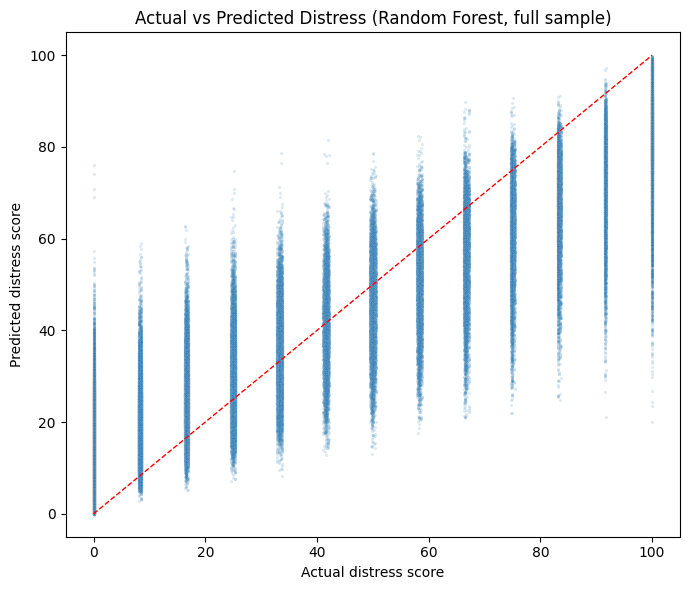

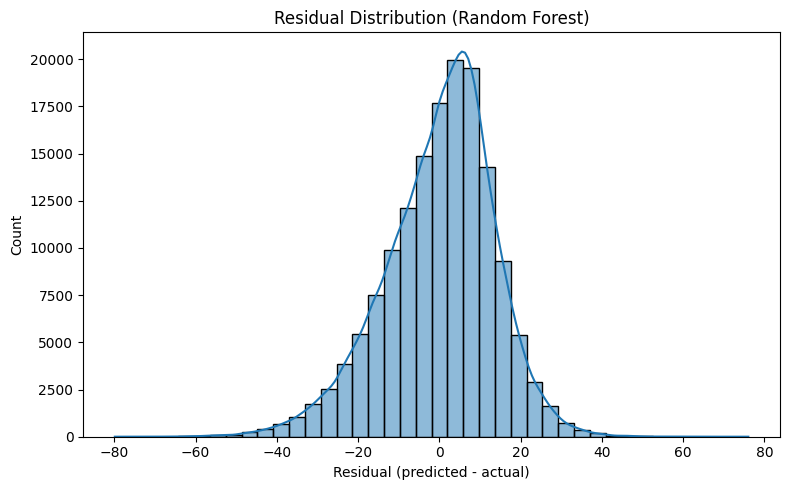

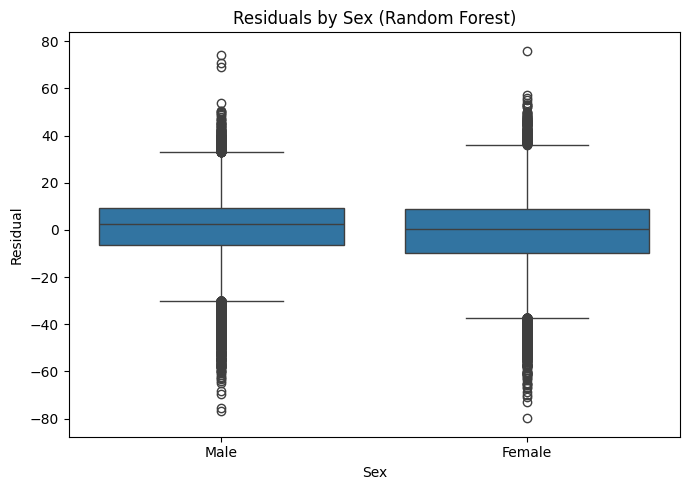

In [48]:
print_header("STEP 14 - FINAL DIAGNOSTICS")

# Actual vs Predicted scatter
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=diagnostic_df[TARGET],
    y=diagnostic_df["predicted_distress"],
    alpha=0.15, s=5
)
lo = min(diagnostic_df[TARGET].min(), diagnostic_df["predicted_distress"].min())
hi = max(diagnostic_df[TARGET].max(), diagnostic_df["predicted_distress"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1)
plt.title("Actual vs Predicted Distress (Random Forest, full sample)")
plt.xlabel("Actual distress score")
plt.ylabel("Predicted distress score")
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(diagnostic_df["residual"], bins=40, kde=True)
plt.title("Residual Distribution (Random Forest)")
plt.xlabel("Residual (predicted - actual)")
plt.tight_layout()
plt.show()

# Residuals by sex
if "sex" in diagnostic_df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=diagnostic_df,
        x=diagnostic_df["sex"].map({1: "Male", 2: "Female"}),
        y="residual"
    )
    plt.title("Residuals by Sex (Random Forest)")
    plt.xlabel("Sex")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

## Step 15 - Save Outputs

In [49]:
print_header("STEP 15 - SAVE OUTPUTS")

oos_df.to_csv("rf_oos_results.csv", index=False)
comparison.to_csv("rf_vs_elasticnet_comparison.csv")
imp_summary.to_csv("rf_feature_importance.csv", index=False)
diagnostic_df.to_csv("rf_final_predictions.csv", index=False)

print("Saved:")
for f in [
    "rf_oos_results.csv",
    "rf_vs_elasticnet_comparison.csv",
    "rf_feature_importance.csv",
    "rf_final_predictions.csv",
]:
    print(" -", f)


STEP 15 - SAVE OUTPUTS
Saved:
 - rf_oos_results.csv
 - rf_vs_elasticnet_comparison.csv
 - rf_feature_importance.csv
 - rf_final_predictions.csv


## Step 16 - Final Takeaways

In [50]:
print_header("STEP 16 - FINAL TAKEAWAYS")

rf_oos = oos_df[oos_df["model"] == "RandomForest"]
en_oos = oos_df[oos_df["model"] == "ElasticNet"]

print("=== Random Forest ===")
print(f"Mean OOS R2:    {rf_oos['test_r2'].mean():.4f} +/- {rf_oos['test_r2'].std():.4f}")
print(f"Mean OOS RMSE:  {rf_oos['test_rmse'].mean():.2f} +/- {rf_oos['test_rmse'].std():.2f}")
print(f"Mean OOS MAE:   {rf_oos['test_mae'].mean():.2f} +/- {rf_oos['test_mae'].std():.2f}")

print("\n=== ElasticNet (Linear Baseline) ===")
print(f"Mean OOS R2:    {en_oos['test_r2'].mean():.4f} +/- {en_oos['test_r2'].std():.4f}")
print(f"Mean OOS RMSE:  {en_oos['test_rmse'].mean():.2f} +/- {en_oos['test_rmse'].std():.2f}")
print(f"Mean OOS MAE:   {en_oos['test_mae'].mean():.2f} +/- {en_oos['test_mae'].std():.2f}")

print(f"\n=== Improvement ===")
print(f"R2:   {en_oos['test_r2'].mean():.4f} -> {rf_oos['test_r2'].mean():.4f} (+{rf_oos['test_r2'].mean() - en_oos['test_r2'].mean():.4f})")
print(f"RMSE: {en_oos['test_rmse'].mean():.2f} -> {rf_oos['test_rmse'].mean():.2f} ({rf_oos['test_rmse'].mean() - en_oos['test_rmse'].mean():.2f})")

print("\nTop 10 most important features (Random Forest):")
print(imp_summary.head(10).to_string(index=False))


STEP 16 - FINAL TAKEAWAYS
=== Random Forest ===
Mean OOS R2:    0.4643 +/- 0.0034
Mean OOS RMSE:  20.89 +/- 0.08
Mean OOS MAE:   16.56 +/- 0.06

=== ElasticNet (Linear Baseline) ===
Mean OOS R2:    0.4523 +/- 0.0027
Mean OOS RMSE:  21.12 +/- 0.05
Mean OOS MAE:   16.77 +/- 0.04

=== Improvement ===
R2:   0.4523 -> 0.4643 (+0.0120)
RMSE: 21.12 -> 20.89 (-0.23)

Top 10 most important features (Random Forest):
            feature  mean_importance  std_importance
sleepdificulty_risk         0.169077        0.000674
      headache_risk         0.117185        0.001447
         dizzy_risk         0.072901        0.001302
   stomachache_risk         0.055865        0.000862
schoolpressure_risk         0.044106        0.000490
      backache_risk         0.031349        0.000344
           age_risk         0.023297        0.000099
    emcsocmed8_risk         0.022420        0.000329
    talkfather_risk         0.019458        0.000676
         irfas_risk         0.017703        0.000059
